In [1]:
###############################################################################
# CHAPTER 5: FORECASTING PRINCIPLES & PRACTICE — PYTHON (COMPLETE SCRIPT)
###############################################################################

# =========================
# 0. INSTALL DEPENDENCIES
# =========================
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn statsforecast utilsforecast fpppy ipywidgets openpyxl 
!{sys.executable} -m pip install statsforecast --only-binary=:all:

In [2]:

# =========================
# 1. GLOBAL SETTINGS
# =========================
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)


import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})

# =========================
# 2. PLOTTING STYLE 
# =========================

import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="all_black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [3]:
# =========================
# 3. LIBRARY IMPORTS
# =========================
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

from pathlib import Path  
    

In [4]:
#data_dir = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/data")
#fig_dir  = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/figures")

data_dir = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("C:/Users/HP/OneDrive - econdse.org/Documents/_Teaching/Forecasting/figures")

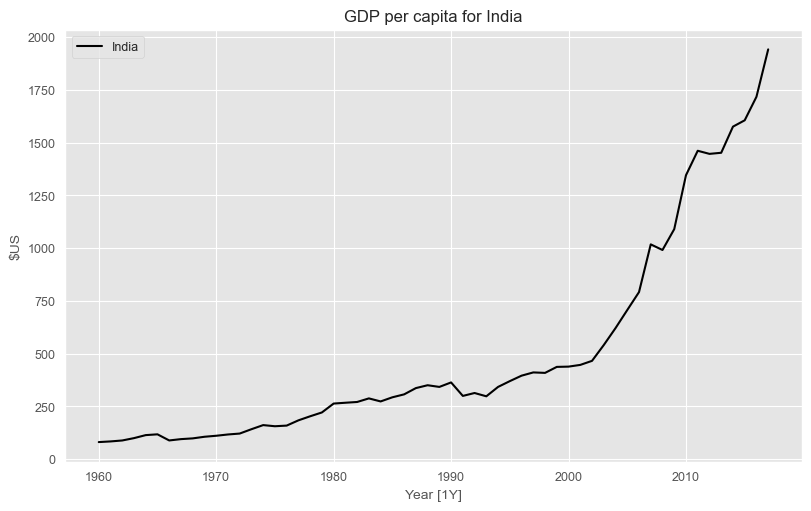

In [5]:
################################################## Fig. 5.2 ###################################################

import pandas as pd, matplotlib.pyplot as plt

file_path = data_dir / "global_economy.csv"

df = pd.read_csv(file_path)
df["GDP_pc"] = df["GDP"] / df["Population"]

def plot_series(d, ids, xlabel="", ylabel="", title=""):
    fig, ax = plt.subplots()

    for i in ids:
        x = d[d.unique_id == i]
        ax.plot(x.ds, x.GDP_pc, label=i)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    return fig

fig = plot_series(
    df,
    ["India"],
    "Year [1Y]",
    "$US",
    "GDP per capita for India"
)

fig.savefig(fig_dir / "fig_05_02.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Temp\ipykernel_11028\4292251967.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


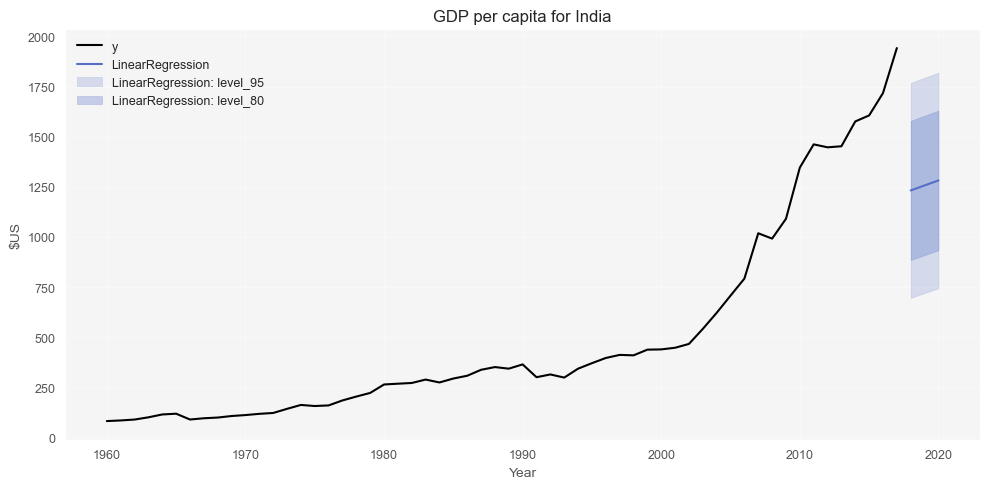

In [6]:
################################################## Fig. 5.3 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np

file_path = data_dir / "global_economy.csv"

# Load data
df = pd.read_csv(file_path)
df["y"] = df.GDP / df.Population
india = df[df.unique_id=="India"][["ds", "y"]].copy()
india["trend"] = range(len(india))

# Train on ALL data and forecast FUTURE
model = LinearRegression().fit(india[["trend"]], india["y"])
future_trend = np.array([[len(india)], [len(india)+1], [len(india)+2]])
future_years = [india["ds"].max() + i for i in range(1, 4)]
y_pred = model.predict(future_trend)

# Prediction intervals
se = np.sqrt(np.sum((india["y"] - model.predict(india[["trend"]]))**2) / (len(india) - 2))
se_pred = se * np.sqrt(1 + 1/len(india) + (future_trend - india["trend"].mean())**2 / np.sum((india["trend"] - india["trend"].mean())**2))
lower_80 = y_pred - stats.t.ppf(0.90, len(india)-2)*se_pred.flatten()
upper_80 = y_pred + stats.t.ppf(0.90, len(india)-2)*se_pred.flatten()
lower_95 = y_pred - stats.t.ppf(0.975, len(india)-2)*se_pred.flatten()
upper_95 = y_pred + stats.t.ppf(0.975, len(india)-2)*se_pred.flatten()

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(india["ds"], india["y"], 'k-', linewidth=1.5, label='y')
ax.plot(future_years, y_pred, color='#5470C6', linewidth=1.5, label='LinearRegression')
ax.fill_between(future_years, lower_95, upper_95, alpha=0.2, color='#5470C6', label='LinearRegression: level_95')
ax.fill_between(future_years, lower_80, upper_80, alpha=0.3, color='#5470C6', label='LinearRegression: level_80')
ax.set_xlabel('Year')
ax.set_ylabel('$US')
ax.set_title('GDP per capita for India')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.set_facecolor('#F5F5F5')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "fig_05_03.png", dpi=300, bbox_inches="tight")
plt.show()

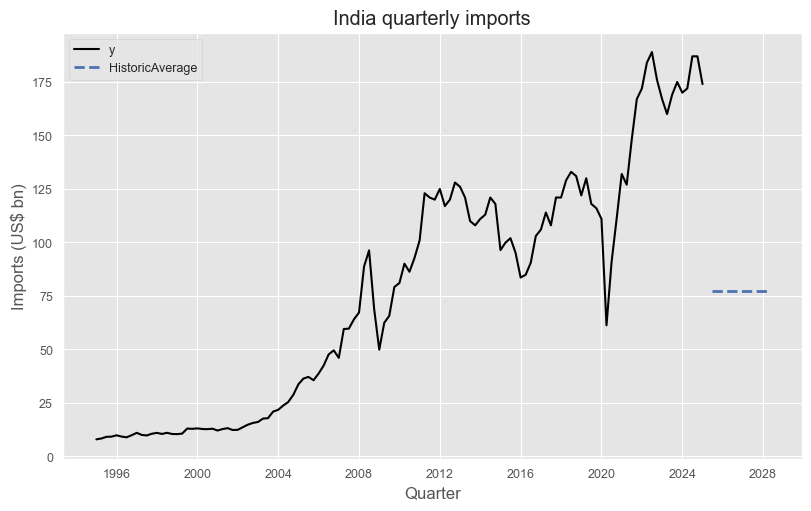

In [8]:
################################################## Fig. 5.4 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

file_path = data_dir / "india_quart_import_1990_2025.csv"

df = pd.read_csv(file_path, parse_dates=["ds"], dayfirst=True)

df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={"import":"y"})[["ds","y"]]
df = df[df.ds.between("1995","2025")]
df["y"] /= 1e9   # USD → USD billions

h =12
ybar = df.y.mean()
future = pd.date_range(df.ds.max(), periods=h+1, freq="QE")[1:]

plt.style.use("ggplot")
plt.plot(df.ds, df.y, c="black", label="y")
plt.plot(future, [ybar]*h, c="#4C72B0", ls="--", lw=2, label="HistoricAverage")

plt.xlabel("Quarter")
plt.ylabel("Imports (US$ bn)")
plt.title("India quarterly imports")
plt.legend()
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}"))
plt.savefig(fig_dir / "fig_05_04.png", dpi=300, bbox_inches="tight")
plt.show()




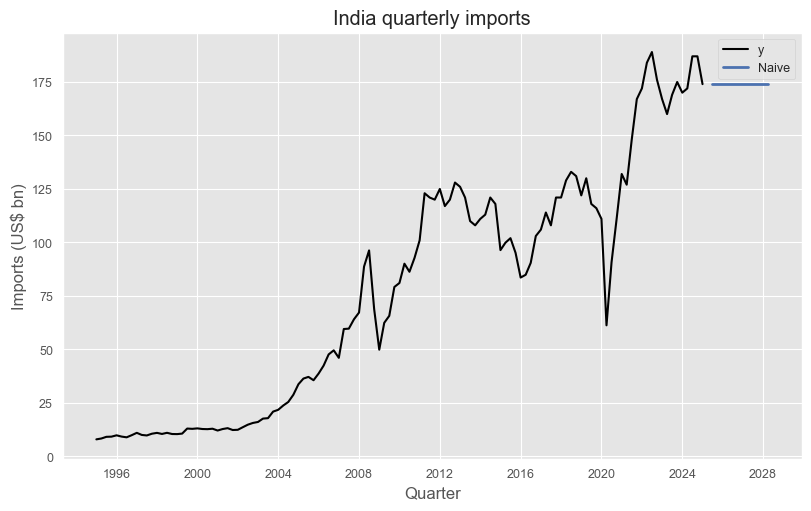

In [9]:
################################################## Fig. 5.5 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import Naive

file_path = data_dir / "india_quart_import_1990_2025.csv"

df = pd.read_csv(file_path,  parse_dates=["ds"], dayfirst=True )

df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={"import":"y"})[["ds","y"]]
df = df[df.ds.between("1995","2025")]
df["y"] /= 1e9   # USD → USD billions

h = 12
last_y = df.y.iloc[-1]
future = pd.date_range(df.ds.max(), periods=h+1, freq="QE")[1:]

plt.style.use("ggplot")
plt.plot(df.ds, df.y, c="black", label="y")
plt.plot(future, [last_y]*h, c="#4C72B0", lw=2, label="Naive")

plt.xlabel("Quarter"); plt.ylabel("Imports (US$ bn)")
plt.title("India quarterly imports")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_05.png", dpi=300, bbox_inches="tight")
plt.show()


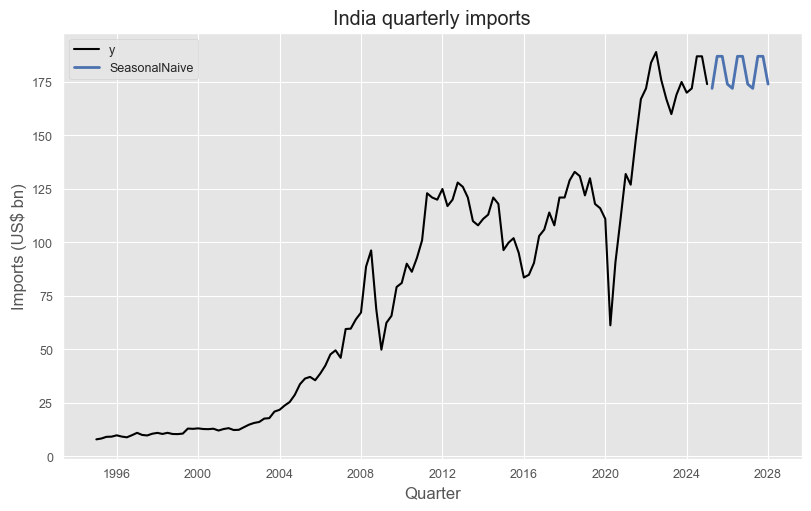

In [10]:
################################################## Fig. 5.6 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

file_path = data_dir / "india_quart_import_1990_2025.csv"

df = pd.read_csv(file_path, parse_dates=["ds"], dayfirst=True)

df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={"import":"y"})[["ds","y"]]
df = df[df.ds.between("1995","2025")]
df["y"] /= 1e9
df["unique_id"] = "India"

h = 12

sf = StatsForecast(
    models=[SeasonalNaive(season_length=4)],
    freq="QE"
)

sf.fit(df)
fc = sf.predict(h=h)

plt.style.use("ggplot")
plt.plot(df.ds, df.y, c="black", label="y")
plt.plot(fc.ds, fc["SeasonalNaive"], c="#4C72B0", lw=2, label="SeasonalNaive")

plt.xlabel("Quarter")
plt.ylabel("Imports (US$ bn)")
plt.title("India quarterly imports")
plt.legend()
plt.savefig(fig_dir / "fig_05_06.png", dpi=300, bbox_inches="tight")
plt.show()


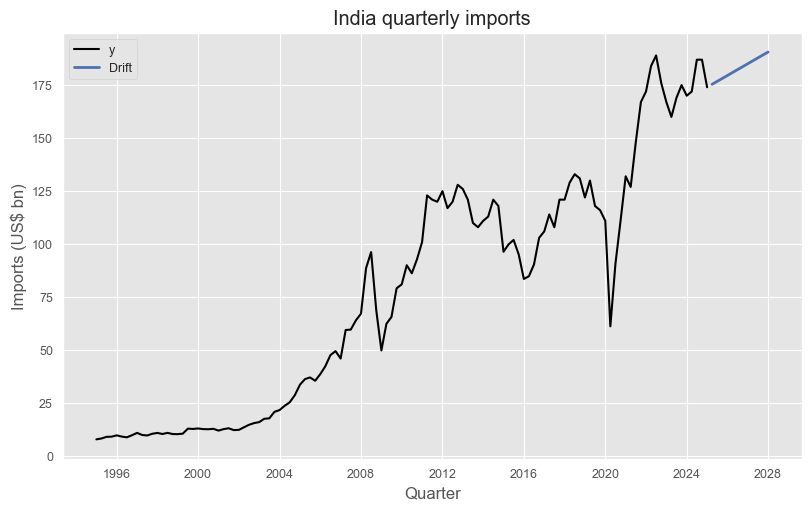

In [24]:
################################################## Fig. 5.7 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import RandomWalkWithDrift

file_path = data_dir / "india_quart_import_1990_2025.csv"

df = pd.read_csv(file_path, parse_dates=["ds"], dayfirst=True)

df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={"import":"y"})[["ds","y"]]
df = df[df.ds.between("1995","2025")]
df["y"] /= 1e9   # US$ → US$ bn

h = 12
sf = StatsForecast(models=[RandomWalkWithDrift()], freq="Q")
fcst = sf.forecast(h=h, df=df.assign(unique_id="India"))

plt.style.use("ggplot")
plt.plot(df.ds, df.y, c="black", label="y")
plt.plot(fcst.ds, fcst["RWD"], c="#4C72B0", lw=2, label="Drift")

plt.xlabel("Quarter"); plt.ylabel("Imports (US$ bn)")
plt.title("India quarterly imports")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_07.png", dpi=300, bbox_inches="tight")
plt.show()


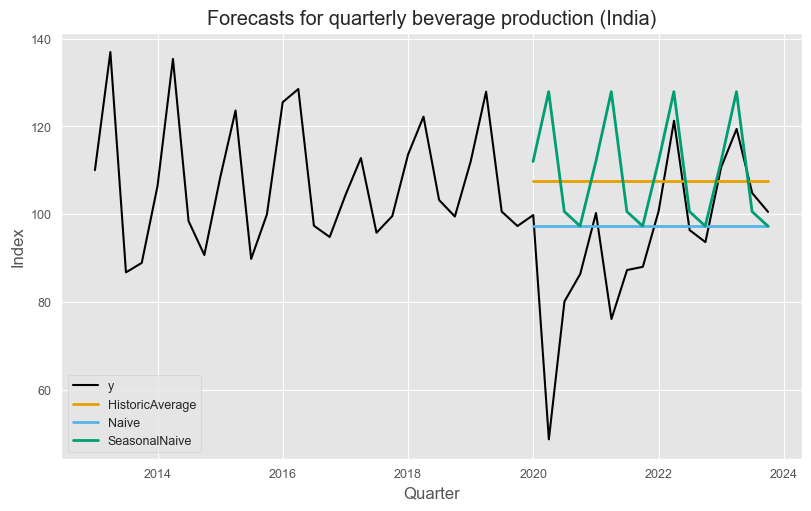

In [11]:
################################################## Fig. 5.8 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, Naive, SeasonalNaive

# data
file_path = data_dir / "india_quart_bevg_prod_index_2013_2023.xlsx"

# data
df = pd.read_excel(file_path, parse_dates=["ds"])

df = df.rename(columns={"beverage_prod_index":"y"})[["ds","y"]]
df["unique_id"] = "India"

# train / test split
train = df[df.ds < "2020-01-01"]
test  = df[df.ds >= "2020-01-01"]

# models
sf = StatsForecast(
    models=[HistoricAverage(), Naive(), SeasonalNaive(4)],
    freq="QE"
)
sf.fit(train)

# forecasts (length = test set)
fcasts = sf.predict(h=len(test)).assign(y=test.y.values)

plt.style.use("ggplot")

# plot full observed series
plt.plot(df.ds, df.y, c="black", label="y")

# plot forecasts over test period
for m,c in zip(
    ["HistoricAverage","Naive","SeasonalNaive"],
    ["#E69F00","#56B4E9","#009E73"]
):
    plt.plot(fcasts.ds, fcasts[m], lw=2, label=m, c=c)

plt.xlabel("Quarter"); plt.ylabel("Index")
plt.title("Forecasts for quarterly beverage production (India)")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_08.png", dpi=300, bbox_inches="tight")
plt.show()



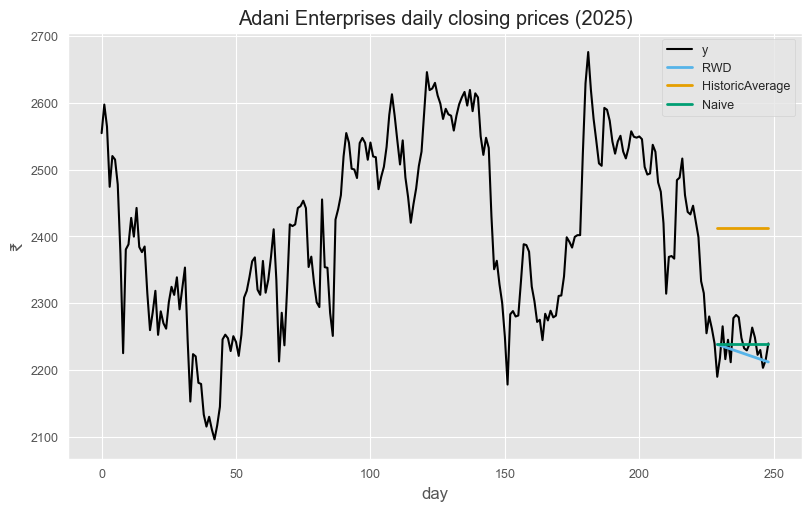

In [25]:
################################################## Fig. 5.9 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, Naive, RandomWalkWithDrift

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["close"].astype(float)
df["unique_id"] = "ADANI"

train, test = df.iloc[:-20].copy(), df.iloc[-20:].copy()
train["ds"] = np.arange(len(train))
test["ds"]  = len(train) + np.arange(len(test))


sf = StatsForecast([RandomWalkWithDrift(), HistoricAverage(), Naive()], freq=1)
sf.fit(train)
fc = sf.predict(h=len(test)).assign(y=test.y.values)

plt.style.use("ggplot")
plt.plot(pd.concat([train,test]).ds, pd.concat([train,test]).y, c="black", label="y")
for m,c in zip(["RWD","HistoricAverage","Naive"],["#56B4E9","#E69F00","#009E73"]):
    plt.plot(fc.ds, fc[m], lw=2, c=c, label=m)

plt.xlabel("day"); plt.ylabel("₹")
plt.title("Adani Enterprises daily closing prices (2025)")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_09.png", dpi=300, bbox_inches="tight")
plt.show()


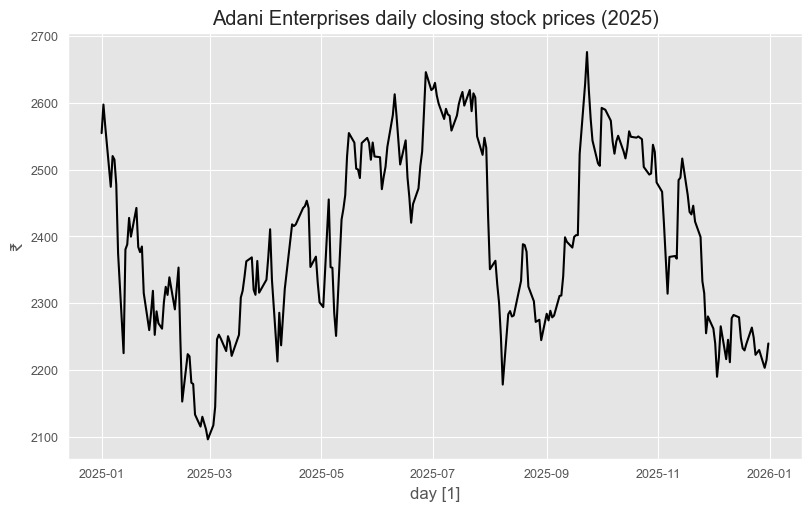

In [12]:
################################################## Fig. 5.10 ###################################################
import pandas as pd, matplotlib.pyplot as plt

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path,
    parse_dates=["ds"]
)

df["y"] = df["close"].astype(float)

plt.style.use("ggplot")
plt.plot(df.ds, df.y, c="black")
plt.xlabel("day [1]")
plt.ylabel("₹")
plt.title("Adani Enterprises daily closing stock prices (2025)")
plt.savefig(fig_dir / "fig_05_10.png", dpi=300, bbox_inches="tight")
plt.show()


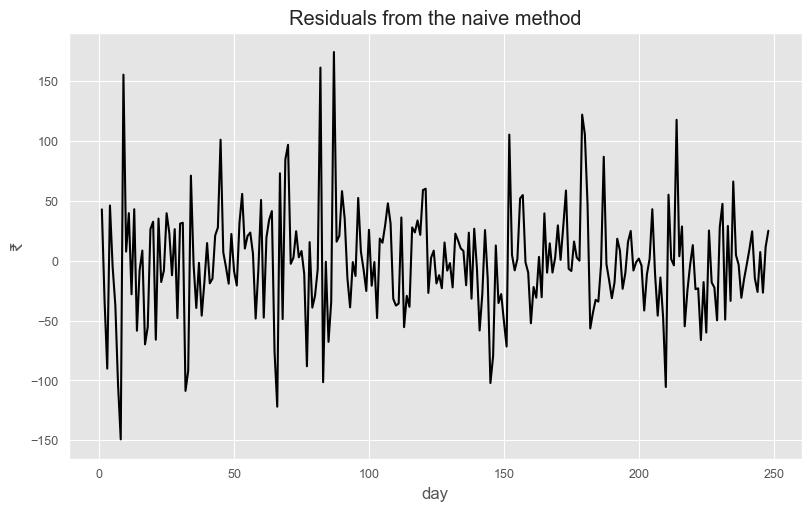

In [13]:
################################################## Fig. 5.11 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# data
file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["close"].astype(float)
df["ds"] = np.arange(len(df))

# naive residuals: y_t - y_{t-1}
resid = df.assign(resid=df.y.diff())

# plot
plt.style.use("ggplot")
plt.plot(resid.ds, resid.resid, c="black")
plt.xlabel("day"); plt.ylabel("₹")
plt.title("Residuals from the naive method")
plt.savefig(fig_dir / "fig_05_11.png", dpi=300, bbox_inches="tight")
plt.show()


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 11.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 11.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 10.1 MB/s  0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.6
    Uninstalling matplotlib-3.10.6:
      Successfully uninstalled matplotlib-3.10.6
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


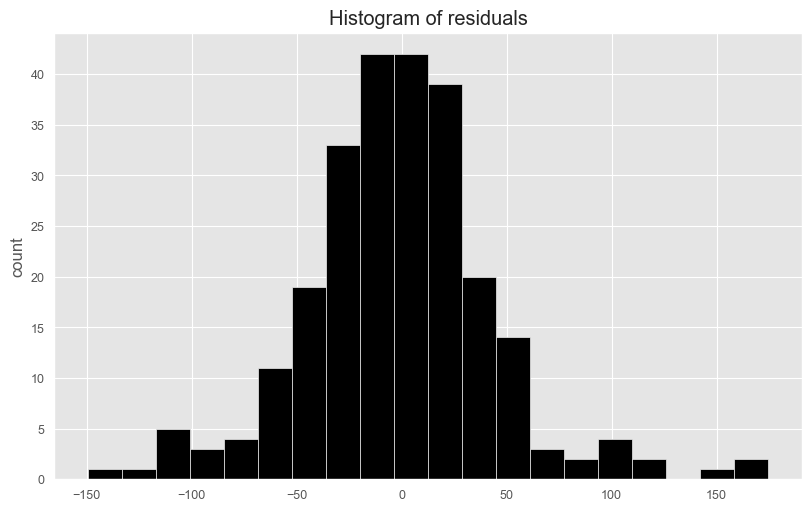

In [14]:
################################################## Fig. 5.12 ###################################################
%pip install -U matplotlib
import pandas as pd, matplotlib.pyplot as plt

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

resid = df.assign(resid=df["close"].astype(float).diff())

plt.style.use("ggplot")
ax = resid["resid"].hist(bins=20, color="black")
ax.set(title="Histogram of residuals", ylabel="count")
plt.savefig(fig_dir / "fig_05_12.png", dpi=300, bbox_inches="tight")
plt.show()


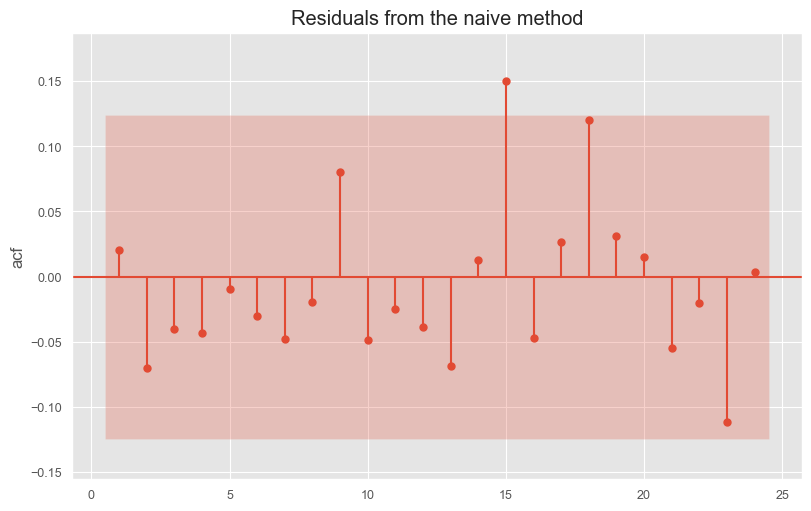

In [15]:
################################################## Fig. 5.13 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

resid = df["close"].astype(float).diff()

plt.style.use("ggplot")
fig = plot_acf(
    resid.dropna(), zero=False, auto_ylims=True,
    bartlett_confint=False, title="Residuals from the naive method"
)
fig.axes[0].set_ylabel("acf")
plt.savefig(fig_dir / "fig_05_13.png", dpi=300, bbox_inches="tight")
plt.show()


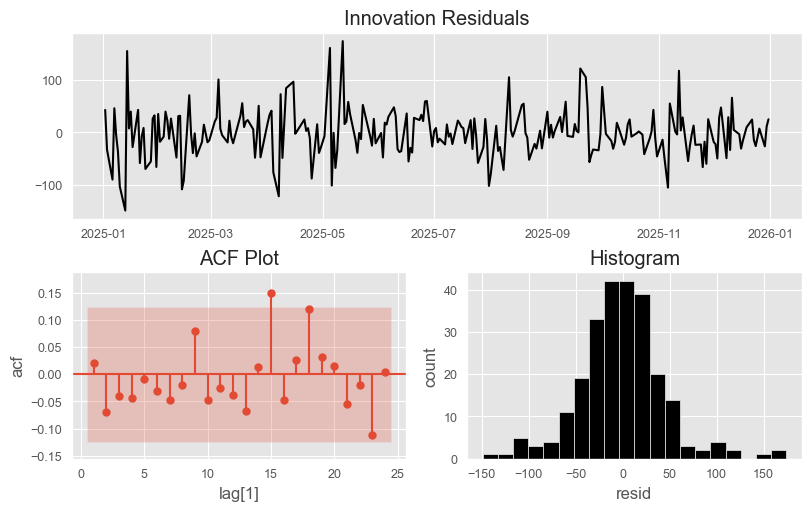

In [16]:
################################################## Fig. 5.14 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

resid = df.assign(resid=df["close"].astype(float).diff())

def plot_diagnostics(data):
    _, ax = plt.subplot_mosaic([["resid","resid"],["acf","hist"]])
    ax["resid"].plot(data.ds, data.resid, c="black")
    ax["resid"].set(title="Innovation Residuals")
    plot_acf(data.resid.dropna(), zero=False,
             bartlett_confint=False, auto_ylims=True, ax=ax["acf"])
    ax["acf"].set(title="ACF Plot", xlabel="lag[1]", ylabel="acf")
    ax["hist"].hist(data.resid, bins=20, color="black")
    ax["hist"].set(title="Histogram", xlabel="resid", ylabel="count")

plt.style.use("ggplot")
plot_diagnostics(resid)
plt.savefig(fig_dir / "fig_05_14.png", dpi=300, bbox_inches="tight")
plt.show()


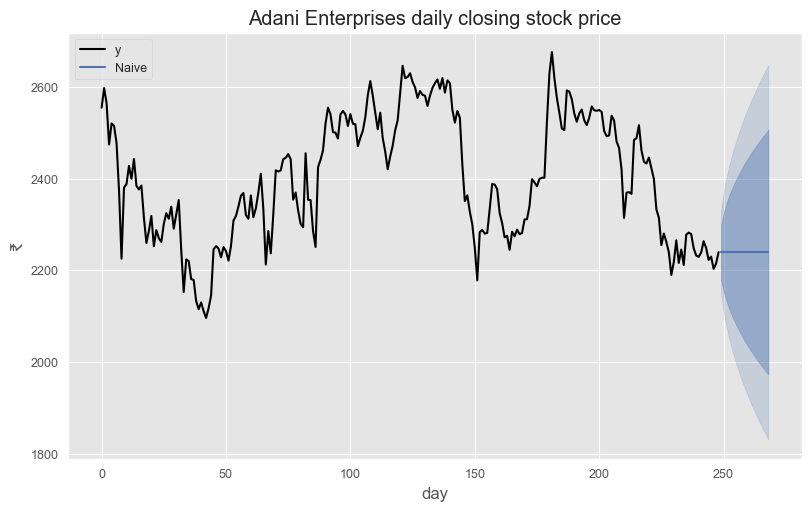

In [17]:
################################################## Fig. 5.15 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import Naive

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["close"].astype(float)
df["unique_id"] = "ADANI"

train, test = df.iloc[:-20].copy(), df.iloc[-20:].copy()
train["ds"] = np.arange(len(train))
test["ds"]  = len(train) + np.arange(len(test))

sf = StatsForecast([Naive()], freq=1)
sf.fit(train)

fc = sf.predict(h=len(test), level=[80,95])
fc["ds"] = len(train) + len(test) + np.arange(len(fc))  

plt.style.use("ggplot")
plt.plot(pd.concat([train,test]).ds,
         pd.concat([train,test]).y, c="black", label="y")

plt.plot(fc.ds, fc["Naive"], c="#4C72B0", label="Naive")
plt.fill_between(fc.ds, fc["Naive-lo-95"], fc["Naive-hi-95"], alpha=.2, color="#4C72B0")
plt.fill_between(fc.ds, fc["Naive-lo-80"], fc["Naive-hi-80"], alpha=.4, color="#4C72B0")

plt.xlabel("day"); plt.ylabel("₹")
plt.title("Adani Enterprises daily closing stock price")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_15.png", dpi=300, bbox_inches="tight")
plt.show()


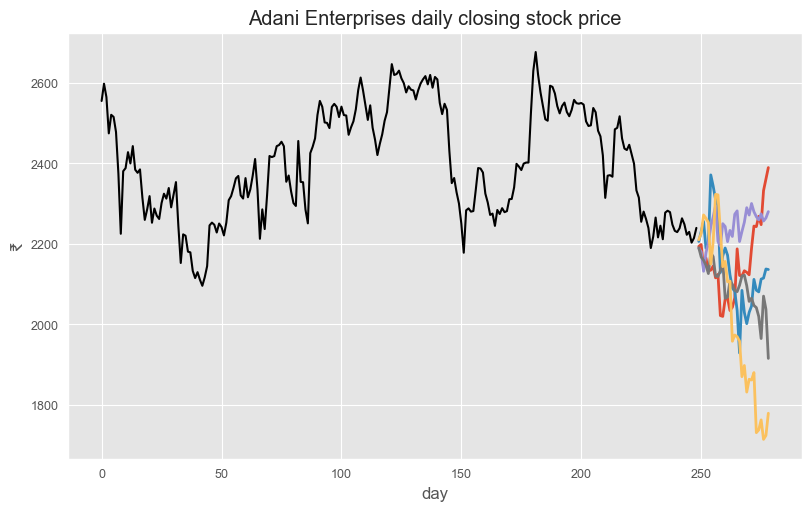

In [18]:
################################################## Fig. 5.16 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import Naive

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["close"].astype(float)
df["unique_id"] = "ADANI"

train = df.copy()
train["ds"] = np.arange(len(train))

sf = StatsForecast([Naive()], freq=1)
sf.forecast(df=train, h=30, fitted=True)
fitted = sf.forecast_fitted_values()

errors = (fitted["y"] - fitted["Naive"]).iloc[1:].to_numpy()
last = train["y"].iloc[-1]

def generate_sim(num_sims=5, h=30):
    eps = np.random.choice(errors, (num_sims, h))
    sims = last + eps.cumsum(axis=1)
    return pd.DataFrame(
        {f"sim_{i}": sims[i] for i in range(num_sims)}
    ).assign(
        unique_id="ADANI",
        ds=lambda x: train.ds.max() + 1 + x.index
    )

sim_df = generate_sim()

plt.style.use("ggplot")
plt.plot(train.ds, train.y, c="black", label="y")
for c in sim_df.filter(like="sim_"):
    plt.plot(sim_df.ds, sim_df[c], lw=2)

plt.xlabel("day"); plt.ylabel("₹")
plt.title("Adani Enterprises daily closing stock price")
plt.savefig(fig_dir / "fig_05_16.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
################################################## Fig. 5.17 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import Naive

# data
file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["close"].astype(float)
df["ds"] = np.arange(len(df))
df["unique_id"] = "ADANI"

# naive + fitted values
sf = StatsForecast([Naive()], freq=1)
sf.forecast(df=df, h=1, fitted=True)      
fitted = sf.forecast_fitted_values()

# bootstrap residuals
errs = (df.y - fitted["Naive"]).iloc[1:].to_numpy()
last = df.y.iloc[-1]

# simulate paths
H, S = 30, 5000
sims = last + np.random.choice(errs, (S, H)).cumsum(axis=1)

# summarize
x = df.ds.max() + 1 + np.arange(H)
mean = sims.mean(0)
lo80, hi80 = np.quantile(sims, [.10, .90], axis=0)
lo95, hi95 = np.quantile(sims, [.025, .975], axis=0)

# plot
plt.style.use("ggplot")
plt.plot(df.ds, df.y, c="black", label="y")
plt.plot(x, mean, c="#4C72B0", label="bootstrap")
plt.fill_between(x, lo95, hi95, alpha=.2, color="#4C72B0")
plt.fill_between(x, lo80, hi80, alpha=.4, color="#4C72B0")
plt.xlabel("day"); plt.ylabel("₹")
plt.title("Adani Enterprises daily closing stock price")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_17.png", dpi=300, bbox_inches="tight")
plt.show()




  unique_id         ds         RWD   RWD-lo-80   RWD-lo-95   RWD-hi-80  \
0     India 2025-03-31  193645.736  178490.381  170467.621  208801.091   
1     India 2025-04-30  194823.848  173263.740  161850.509  216383.956   
2     India 2025-05-31  196001.960  169441.456  155381.174  222562.465   
3     India 2025-06-30  197180.072  166332.848  150003.314  228027.296   
4     India 2025-07-31  198358.184  163672.297  145310.698  233044.071   

    RWD-hi-95  
0  216823.851  
1  227797.188  
2  236622.746  
3  244356.830  
4  251405.671  


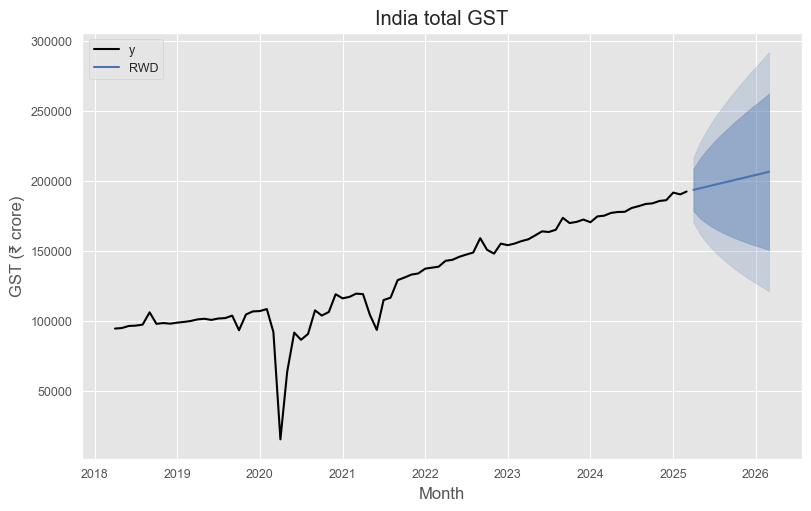

In [10]:
################################################## Fig. 5.19 ###################################################
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsforecast import StatsForecast
from statsforecast.models import Naive

file_path = data_dir / "monthly_total_GST_2018_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df.columns = df.columns.str.lower().str.replace(" ", "_")
df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df["y"] = df["total_gst_(in_crores)"].astype(float)
df["unique_id"] = "India"

# STL decomposition
stl = STL(df.y.to_numpy(), period=12, robust=True).fit()
train_df = df.assign(y=df.y - stl.seasonal)   # ✅ y = seasonally adjusted

# Drift forecast
sf = StatsForecast([RandomWalkWithDrift()], freq="ME")
fcst = sf.forecast(df=train_df, h=12, level=[80,95], fitted=True)
print(fcst.head())

# Plot 
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.plot(train_df.ds, train_df.y, c="black", label="y")
plt.plot(fcst.ds, fcst["RWD"], c="#4C72B0", label="RWD")

plt.fill_between(fcst.ds, fcst["RWD-lo-95"], fcst["RWD-hi-95"],
                 alpha=.2, color="#4C72B0")
plt.fill_between(fcst.ds, fcst["RWD-lo-80"], fcst["RWD-hi-80"],
                 alpha=.4, color="#4C72B0")

plt.xlabel("Month"); plt.ylabel("GST (₹ crore)")
plt.title("India total GST")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_19.png", dpi=300, bbox_inches="tight")
plt.show()



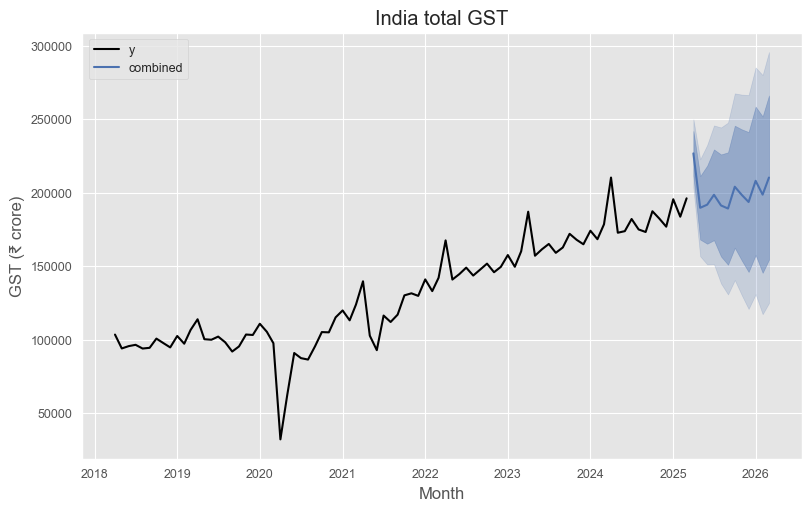

In [11]:
################################################## Fig. 5.20 ###################################################
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive

# ---------------- data ----------------
file_path = data_dir / "monthly_total_GST_2018_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df.columns = df.columns.str.lower().str.replace(" ", "_")
df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df["y"] = df["total_gst_(in_crores)"].astype(float)
df["unique_id"] = "India"

# ---------------- STL ----------------
stl = STL(df.y.to_numpy(), period=12, robust=True).fit()
train_df = df.assign(
    seasonal=stl.seasonal,
    y_adj=df.y - stl.seasonal
)

# ---------------- forecasts ----------------
sf_adj = StatsForecast([RandomWalkWithDrift()], freq="ME")
adj_fcst = sf_adj.forecast(
    df=train_df.assign(y=train_df.y_adj),
    h=12, level=[80,95]
)

sf_seas = StatsForecast([SeasonalNaive(12)], freq="ME")
seas_fcst = sf_seas.forecast(
    df=train_df.assign(y=train_df.seasonal),
    h=12
)

# ---------------- recombine ----------------
fcst = (
    adj_fcst.merge(seas_fcst, on=["unique_id","ds"], suffixes=("_adj","_seas"))
    .assign(
        combined = lambda x: x["RWD"] + x["SeasonalNaive"],
        lo_95 = lambda x: x["RWD-lo-95"] + x["SeasonalNaive"],
        hi_95 = lambda x: x["RWD-hi-95"] + x["SeasonalNaive"],
        lo_80 = lambda x: x["RWD-lo-80"] + x["SeasonalNaive"],
        hi_80 = lambda x: x["RWD-hi-80"] + x["SeasonalNaive"],
    )
)

# ---------------- plot ----------------
plt.style.use("ggplot")
plt.plot(train_df.ds, train_df.y, c="black", label="y")
plt.plot(fcst.ds, fcst.combined, c="#4C72B0", label="combined")

plt.fill_between(fcst.ds, fcst.lo_95, fcst.hi_95, alpha=.2, color="#4C72B0")
plt.fill_between(fcst.ds, fcst.lo_80, fcst.hi_80, alpha=.4, color="#4C72B0")

plt.xlabel("Month")
plt.ylabel("GST (₹ crore)")
plt.title("India total GST")
plt.legend()
plt.savefig(fig_dir / "fig_05_20.png", dpi=300, bbox_inches="tight")
plt.show()



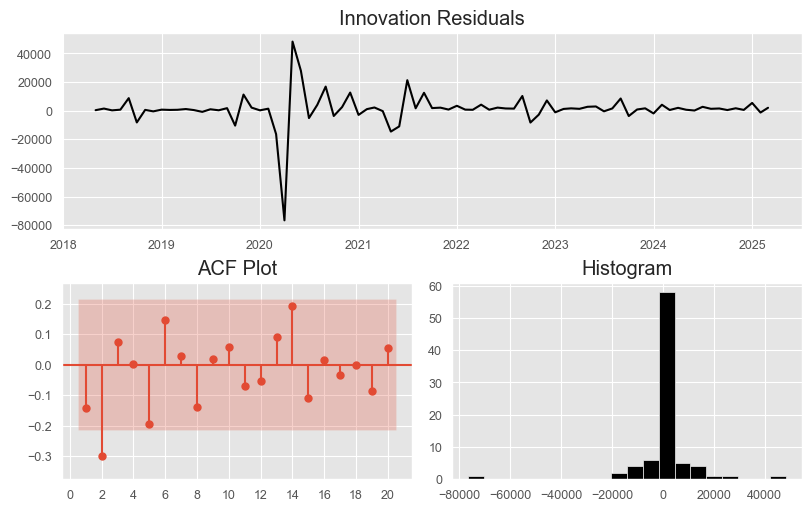

In [16]:
################################################## Fig. 5.21 ###################################################
import pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf

# ---------- data ----------
file_path = data_dir / "monthly_total_GST_2018_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df.columns = df.columns.str.lower().str.replace(" ", "_")
df["ds"] = pd.to_datetime(df["ds"], dayfirst=True)
df["y"] = df["total_gst_(in_crores)"].astype(float)

# ---------- STL + naive fitted + TRUE residuals ----------
stl = STL(df["y"], period=12, robust=True).fit()
df = df.assign(
    seasonal=stl.seasonal,
    fitted=lambda x: x["y"].shift(1) - x["seasonal"].shift(1) + x["seasonal"],
    resid=lambda x: x["y"] - x["fitted"]
)

# ---------- diagnostics ----------
plt.style.use("ggplot")
fig, ax = plt.subplot_mosaic([["resid","resid"],["acf","hist"]])

ax["resid"].plot(df.ds, df.resid, c="black")
ax["resid"].set(title="Innovation Residuals")

plot_acf(df.resid.dropna(), zero=False, bartlett_confint=False,
         auto_ylims=True, ax=ax["acf"])
ax["acf"].set_xticks(range(0, 21, 2))
ax["acf"].set(title="ACF Plot")

ax["hist"].hist(df.resid.dropna(), bins=20, color="black")
ax["hist"].set(title="Histogram")

plt.style.use("ggplot")
#plot_diagnostics(resid)
plt.savefig(fig_dir / "fig_05_21.png", dpi=300, bbox_inches="tight")
plt.show()



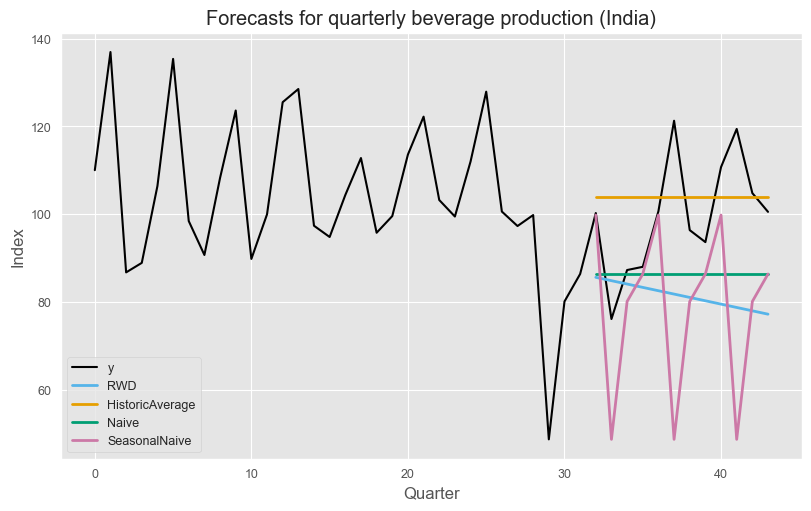

In [13]:
################################################## Fig. 5.23 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage, Naive, RandomWalkWithDrift, SeasonalNaive
)

# data
file_path = data_dir / "india_quart_bevg_prod_index_2013_2023.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["beverage_prod_index"].astype(float)
df["unique_id"] = "India"

# train / test split (like Fig 5.23)
train = df[df.ds.dt.year <= 2020].copy()
test  = df[df.ds.dt.year > 2020].copy()

# reindex time (same style as Adani)
train["ds"] = np.arange(len(train))
test["ds"]  = len(train) + np.arange(len(test))

# models (Fig 5.23 set)
sf = StatsForecast(
    models=[
        RandomWalkWithDrift(),
        HistoricAverage(),
        Naive(),
        SeasonalNaive(4)   # quarterly seasonality
    ],
    freq=1
)

sf.fit(train)
fc = sf.predict(h=len(test)).assign(y=test.y.values)

# plot
plt.style.use("ggplot")
plt.plot(pd.concat([train,test]).ds,
         pd.concat([train,test]).y,
         c="black", label="y")

for m,c in zip(
    ["RWD","HistoricAverage","Naive","SeasonalNaive"],
    ["#56B4E9","#E69F00","#009E73","#CC79A7"]
):
    plt.plot(fc.ds, fc[m], lw=2, c=c, label=m)

plt.xlabel("Quarter")
plt.ylabel("Index")
plt.title("Forecasts for quarterly beverage production (India)")
plt.legend()
plt.savefig(fig_dir / "fig_05_23.png", dpi=300, bbox_inches="tight")
plt.show()


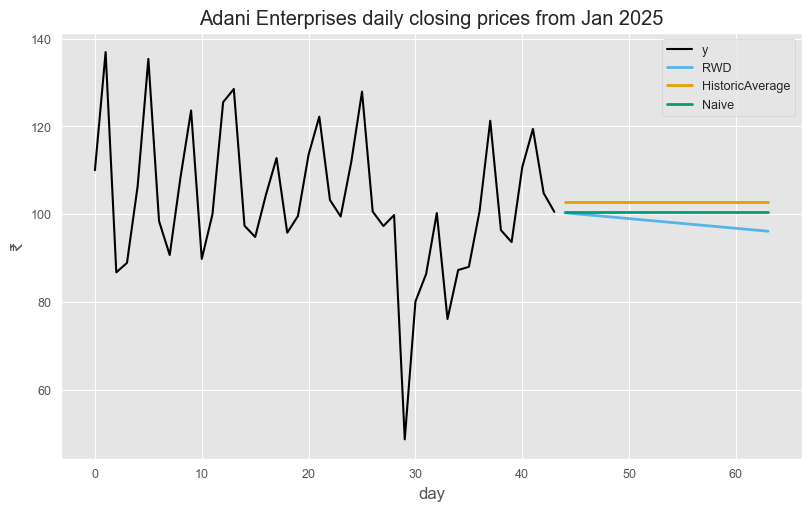

In [23]:
################################################## Fig. 5.24 ###################################################
train = df.copy()
train["ds"] = np.arange(len(train))

h = 20   # forecast next 20 trading days

sf = StatsForecast(
    models=[RandomWalkWithDrift(), HistoricAverage(), Naive()],
    freq=1
)

fc = sf.forecast(df=train, h=h)

# place forecasts after last observed day
fc["ds"] = train["ds"].max() + 1 + np.arange(h)

plt.style.use("ggplot")
plt.plot(train.ds, train.y, c="black", label="y")

for m, c in zip(
    ["RWD", "HistoricAverage", "Naive"],
    ["#56B4E9", "#E69F00", "#009E73"]
):
    plt.plot(fc.ds, fc[m], lw=2, c=c, label=m)

plt.xlabel("day"); plt.ylabel("₹")
plt.title("Adani Enterprises daily closing prices from Jan 2025")
plt.legend(); 
plt.savefig(fig_dir / "fig_05_24.png", dpi=300, bbox_inches="tight")
plt.show()





  unique_id   ds   Naive  Naive-lo-80  Naive-hi-80       y
0     Adani  249  2239.7     2181.356     2298.044  2260.0
1     Adani  250  2239.7     2157.189     2322.211  2279.8
2     Adani  251  2239.7     2138.645     2340.755  2279.5
3     Adani  252  2239.7     2123.011     2356.389  2259.1
4     Adani  253  2239.7     2109.238     2370.162  2274.1


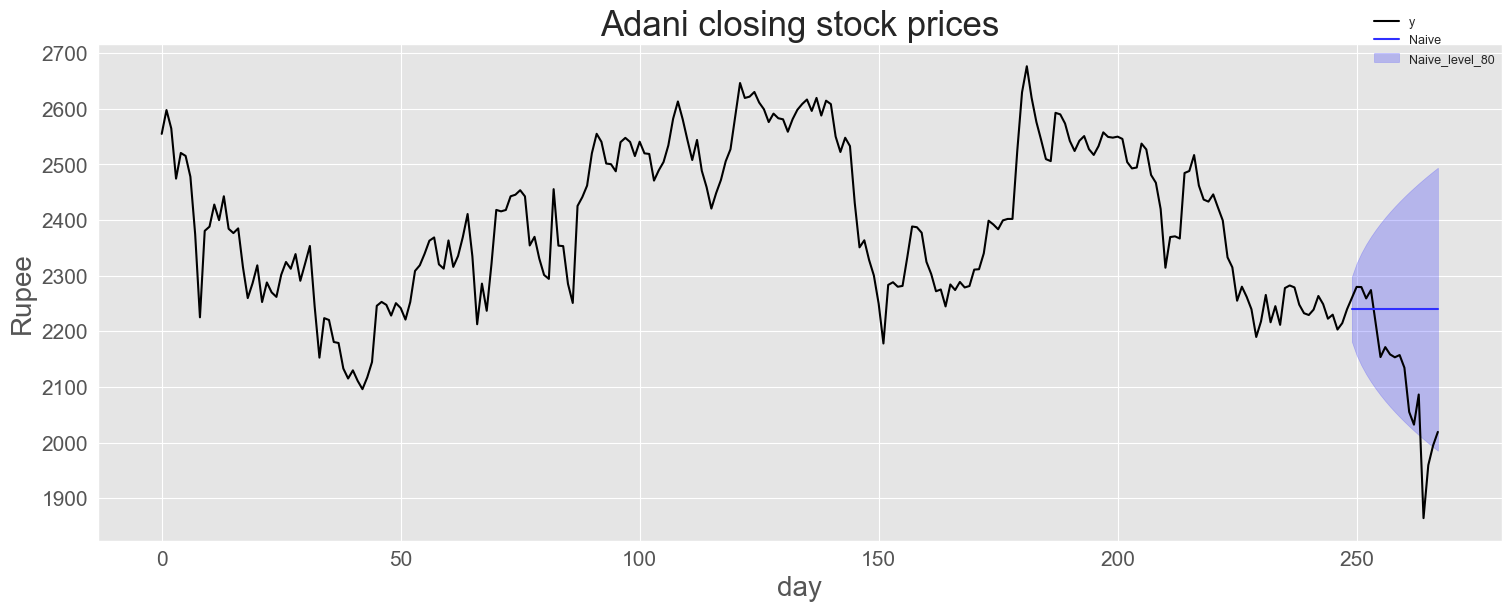

In [30]:
################################################## Fig. 5.25 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import Naive

file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

# Add the required 'unique_id' column
df['unique_id'] = 'Adani'

# Rename 'close' to 'y' (StatsForecast expects this)
df = df.rename(columns={'close': 'y'})

# Reorder columns: unique_id, ds, y
df = df[['unique_id', 'ds', 'y']]


train_df = df.loc[lambda x: x["ds"].dt.year == 2025].copy()
test_df = df.loc[lambda x: x["ds"].dt.year == 2026].copy()
test_df = test_df.head(19)

train_df["ds"] = np.arange(len(train_df["ds"]))
test_df["ds"] = len(train_df) +  np.arange(19)

naive_model = Naive()

sf = StatsForecast(models=[naive_model], freq=1)
preds = (
    sf.forecast(h=19, level=[80], df=train_df)
    .assign(y=test_df["y"].to_numpy())
)
print(preds.head())
plot_series(train_df, preds, level=[80],
    xlabel="day", ylabel="Rupee",
    title="Adani closing stock prices",
    palette="black_and_blue", rm_legend=False,)



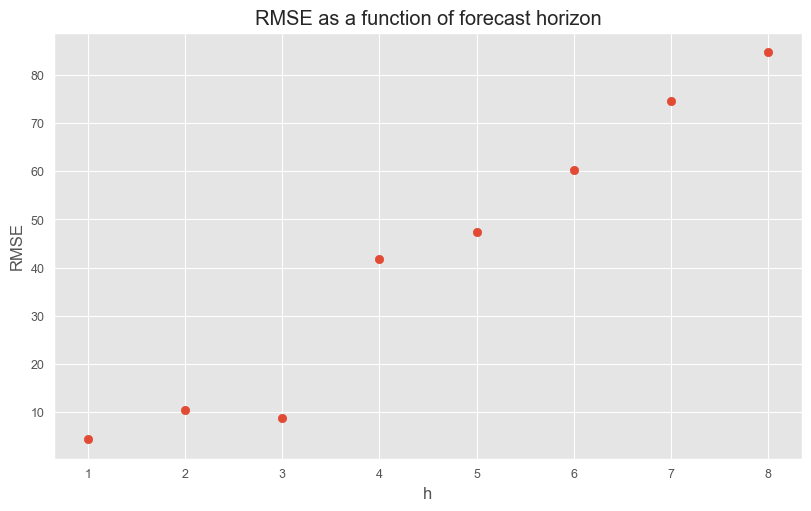

In [21]:
################################################## Fig. 5.28 ###################################################
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import RandomWalkWithDrift
from utilsforecast.losses import rmse
from utilsforecast.evaluation import evaluate

# data
file_path = data_dir / "adani_daily_closing_price_2025.xlsx"
df = pd.read_excel(file_path, parse_dates=["ds"])

df["y"] = df["close"].astype(float)
df["unique_id"] = "ADANI"
df["ds"] = np.arange(len(df))

# use full series 
train_df = df.copy()

# RMSE over horizons
rmses, horizons = [], np.arange(1, 9)

for h in horizons:
    sf = StatsForecast([RandomWalkWithDrift()], freq=1)
    cv = sf.cross_validation(
        df=train_df, h=h, step_size=1, test_size=200
    )
    ev = evaluate(cv, metrics=[rmse], models=["RWD"])
    rmses.append(ev["RWD"].iloc[0])

# plot
plt.style.use("ggplot")
plt.scatter(horizons, rmses)
plt.xlabel("h"); plt.ylabel("RMSE")
plt.title("RMSE as a function of forecast horizon")
plt.savefig(fig_dir / "fig_05_28.png", dpi=300, bbox_inches="tight")
plt.show()
